In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size=5, color='red'><b>ch2_군집분석</b></font>
# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
- 클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1" 
# sklearn의 로직들이 멀티스레드로 실행 => 단일 스레드 작업을 하도록. sklearn 실행 전에 실행해줘야 warning 방지

1. scikit-learn 내부는 "멀티스레드" 연산
scikit-learn의 많은 알고리즘(특히 n_jobs 옵션이 있는 것, 예: RandomForest, SVM 등)은

내부적으로 OpenMP(병렬 연산 라이브러리)를 이용해서

CPU 코어 여러 개를 자동으로 사용함

2. 불필요한 경고, CPU 점유, 오버헤드 방지
실험, 배포, 서버 등에서는 단일 스레드로 제한하고 싶을 때가 많음

예를 들어,

Docker, Jupyter, 서버환경, M1/M2 macOS, 일부 클라우드 환경 등에서는

너무 많은 스레드를 쓸 경우 **경고(warning)**가 뜨거나,

과도한 CPU 사용, 메모리 폭주, 느려짐이 생길 수 있음

특히, sklearn과 numpy, pytorch 등이 서로 멀티스레드로 연산할 때

한 머신에 여러 세션이 돌거나,

작업이 중첩될 때

OMP 관련 동시성 경고, 성능저하 발생!

3. 실험 재현성, 리소스 제한
실험 결과 재현을 위해,

서버/클러스터에서 리소스 제한이 필요할 때

혹은 성능 측정, 벤치마크 시 정확한 스레드 수 통제 필요

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘
- 클러스터의 중심을 찾아가는 알고리즘
- 세부 알고리즘 : 교안 6p

In [5]:
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
plt.rc('font', family = 'Hancom Gothic')
plt.rc('axes', unicode_minus=False)

In [15]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
X, y =make_classification(n_samples=20, # 데이터 갯수 : 기본값 100
                          n_features=2, # 독립변수 : 기본값 20
                          n_informative=2, # 종속변수의 값에 영향을 미치는 독립변수 개수
                          n_classes=2, # 종속변수의 그룹 수
                          n_redundant=0, # feature 중에 쓸모 없는 feature 수, noise 수
                          n_repeated=0, # informative 반복. repeated는 기존 컬럼의 단순 복사(=완전 새 정보 X)
                          n_clusters_per_class=1, # 각 종속변수 그룹별 서브 그룹 수, 1 => 서브그룹이 1개 == 총 그룹.
                         random_state=123)

import numpy as np
np.c_[X,y][:3]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

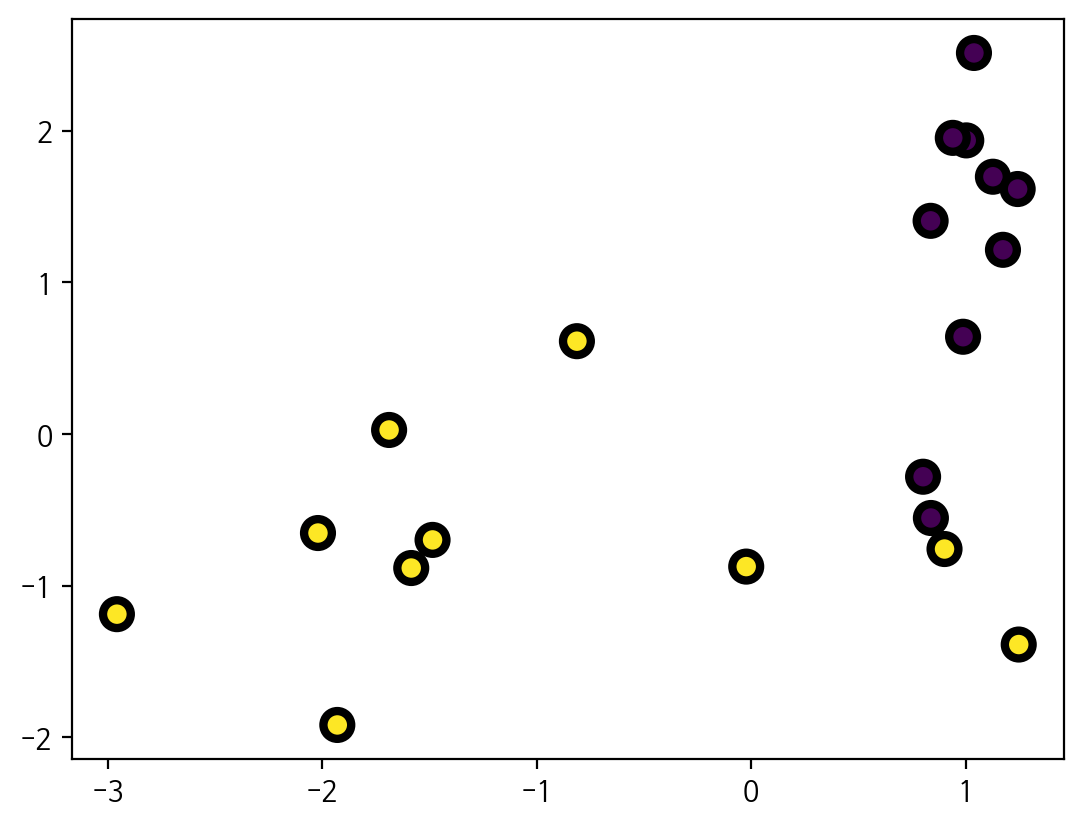

In [25]:
plt.scatter(x=X[:,0],y=X[:,1],c=y, s=100, edgecolors='k', lw=3)
plt.show()

In [29]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 타겟변수 군의 개수 : 2개군으로 분류
              init = 'k-means++', # 첫 clustering point를 어떻게 잡을 것인가에 대한 지시. random : 중심점 랜덤, k-means++ : 초기 중심을 서로 멀리 초기화
              n_init = 10, # 초기 중심점을 10번 잡아 시도해서 가장 괜찮은 모델을 사용한다. 'auto' => 스스로 제일 괜찮은 곳을 찾아서 실행하겠다
              max_iter=300, # 각 실행을 300번 반복 중심옮기기
              )
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [51]:
c0, c1 = model.cluster_centers_ # 모델이 최종적으로 정한 두 중심점

In [46]:
print('model Label :', model.labels_) # X값을 가지고 모델이 나눈 값
print('실   제   값 :', y)
print('예   측   값 :',model.predict(X))

model Label : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
실   제   값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예   측   값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]


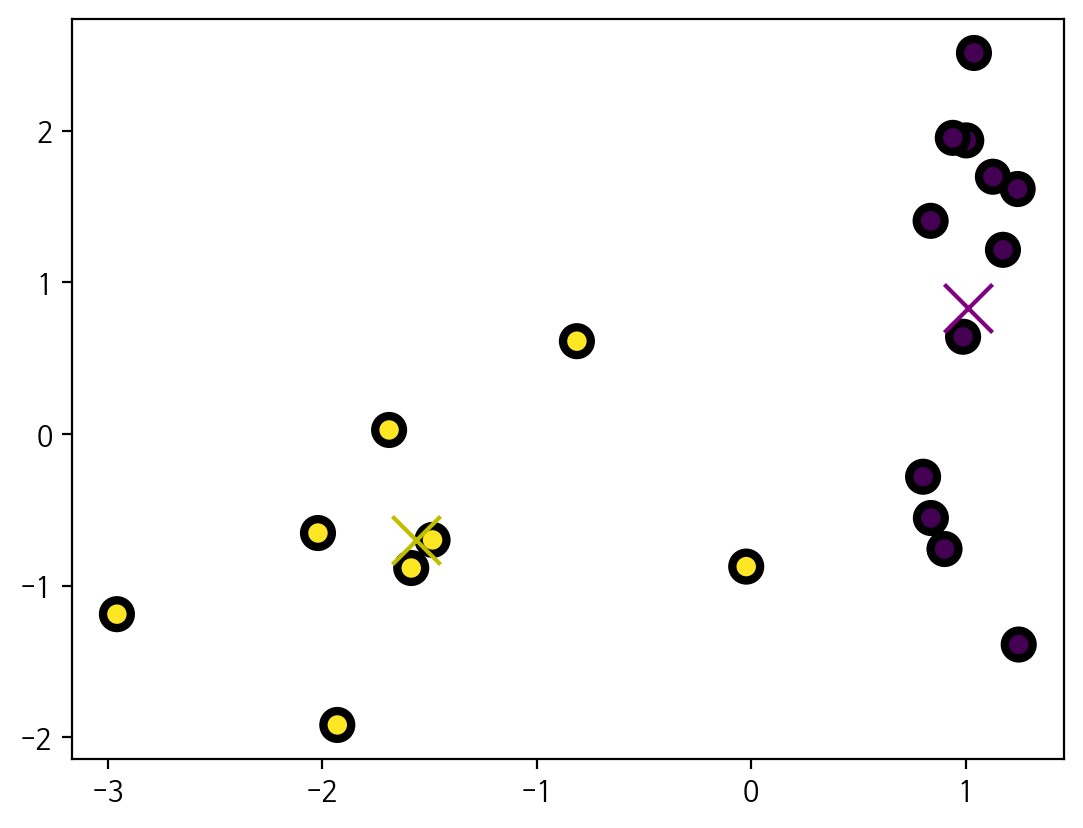

In [64]:
plt.scatter(x=X[:,0],y=X[:,1], c=model.predict(X), s=100, edgecolors='k', lw=3)
plt.scatter(x=c0[0], y=c0[1], s=300, marker='x', c='purple')
plt.scatter(x=c1[0],y=c1[1], s=300, marker='x', c='y')
plt.show()

In [67]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
scaled_X = scaler.fit_transform(X)
scaled_X

model_forNormal = KMeans(n_clusters=2,
                         n_init = 10,
                         init = 'k-means++',
                         max_iter=300
                        )

model_forNormal.fit(scaled_X)

KMeans(n_clusters=2, n_init=10)

In [70]:
n1, n2 = model_forNormal.cluster_centers_

In [81]:
scaled_X[model_forNormal.labels_==0]

array([[ 0.3821159 ,  0.92411441],
       [ 0.46005267,  0.88789162],
       [ 0.76493676, -0.64410538],
       [ 0.51161542,  0.85921456],
       [ 0.83395074, -0.55183889],
       [ 0.55350265,  0.83284742],
       [ 0.94318094, -0.33227958],
       [ 0.43387458,  0.90097328],
       [ 0.60980605,  0.79255068],
       [ 0.66821427, -0.74396888],
       [ 0.83902767,  0.54408875],
       [ 0.69516439,  0.7188508 ]])

model_Label   : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
Nornalize 이후 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  실제 y 데이터 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


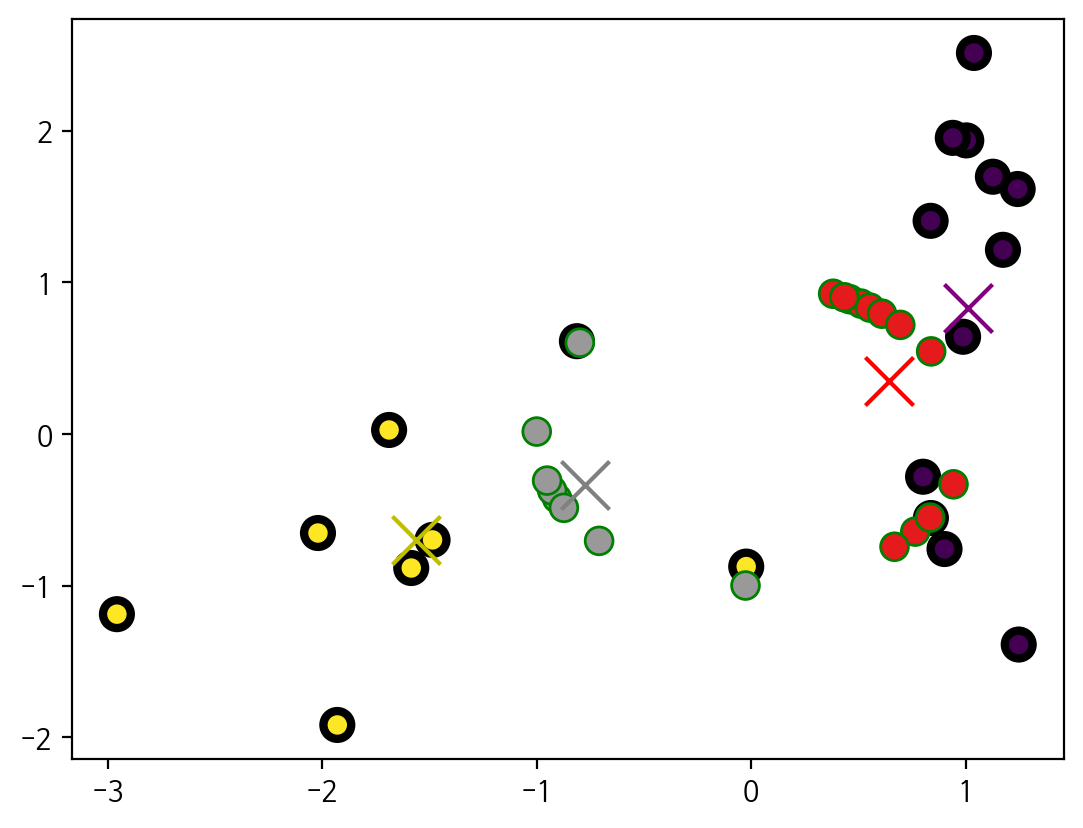

In [86]:
print('model_Label   :', model.labels_)
print('Nornalize 이후 :',model_forNormal.labels_)
print('  실제 y 데이터 :',y)

plt.scatter(x=X[:,0],y=X[:,1], c=model.predict(X), s=100, edgecolors='k', lw=3)
plt.scatter(x=scaled_X[:,0],y=scaled_X[:,1], c=model_forNormal.labels_, s=100, edgecolors='g', lw=1, cmap='Set1')
plt.scatter(x=c0[0], y=c0[1], s=300, marker='x', c='purple')
plt.scatter(x=c1[0],y=c1[1], s=300, marker='x', c='y')
plt.scatter(x=n1[0], y=n1[1], s=300, marker='x', c='red')
plt.scatter(x=n2[0],y=n2[1], s=300, marker='x', c='gray')
plt.show()

### Normalize 한 자료를 토대로 clustering하면 작은 scale에서 계산하고 찾아가며 효율성이 좋아진다
- clustering 이 잘 안나오면 이렇게 데이터를 체크해서 사용하면 좋다

## K-Means의 한계점
- 군의 특성이 다를 경우 : 
    * size, 크기
    * Densities, 밀도
    * Non-globular shapes, 비 구형의 경우
- 이상치를 포함할 경우 => boxplot으로 체크, 이상치를 조정하거나 삭제 후 clustering해야..
### 군의 크기가 다른 경우

In [112]:
np.random.seed(0)
# 평균 -10, 표준편차가 2인 10행 2열 데이터 : group 0
group0 = np.random.normal(-10,2,(10,2))
y = np.full(group0.shape[0],0)
group0 = np.c_[group0,y]
group0

array([[ -6.47189531,  -9.19968558,   0.        ],
       [ -8.04252403,  -5.5182136 ,   0.        ],
       [ -6.26488402, -11.95455576,   0.        ],
       [ -8.09982316, -10.30271442,   0.        ],
       [-10.2064377 ,  -9.178803  ,   0.        ],
       [ -9.71191286,  -7.09145299,   0.        ],
       [ -8.47792455,  -9.75664997,   0.        ],
       [ -9.11227353,  -9.33265135,   0.        ],
       [ -7.01184185, -10.41031653,   0.        ],
       [ -9.3738646 , -11.70819148,   0.        ]])

In [113]:
# 평균 10, 표준편차가 2인 10행 2열 데이터 : group 1
group1 = np.random.normal(10,2,(10,2))
y = np.full(group1.shape[0],1)
group1 = np.c_[group1,y]
group1

array([[ 4.89402037, 11.30723719,  1.        ],
       [11.7288724 ,  8.51566996,  1.        ],
       [14.53950925,  7.09126865,  1.        ],
       [10.09151703,  9.6256323 ,  1.        ],
       [13.06555843, 12.93871754,  1.        ],
       [10.30989485, 10.75632504,  1.        ],
       [ 8.2244285 ,  6.03840706,  1.        ],
       [ 9.3041757 , 10.31269794,  1.        ],
       [12.46058136, 12.4047597 ,  1.        ],
       [ 9.22534637,  9.3953945 ,  1.        ]])

In [114]:
# 평균 0, 표준편차가 5인 100행 2열 데이터 : group 2
group2 = np.random.normal(0,5,(100,2))
y = np.full(group2.shape[0],2)
y
group2 = np.c_[group2,y]
group2

array([[ -5.24276483,  -7.10008969,   2.        ],
       [ -8.53135095,   9.75387698,   2.        ],
       [ -2.54826091,  -2.19037151,   2.        ],
       [ -6.2639768 ,   3.88745178,   2.        ],
       [ -8.06948924,  -1.0637014 ,   2.        ],
       [ -4.47733281,   1.93451249,   2.        ],
       [ -2.55402569,  -5.90316092,   2.        ],
       [ -0.14091114,   2.14165935,   2.        ],
       [  0.33258611,   1.51235949,   2.        ],
       [ -3.17161047,  -1.81370583,   2.        ],
       [ -3.36230224,  -1.79776581,   2.        ],
       [ -4.06573141,  -8.63141301,   2.        ],
       [  0.88713071,  -2.00890468,   2.        ],
       [ -8.15099173,   2.31391128,   2.        ],
       [ -4.53649182,   0.25972698,   2.        ],
       [  3.64545281,   0.64491455,   2.        ],
       [  5.69700342,  -6.1741291 ,   2.        ],
       [  2.01170821,  -3.42405045,   2.        ],
       [ -4.35398575,  -2.89424832,   2.        ],
       [ -1.55776266,   0.28082

In [115]:
data = np.r_[group0,group1,group2]
data[::20], data.shape

(array([[-6.47189531, -9.19968558,  0.        ],
        [-5.24276483, -7.10008969,  2.        ],
        [-5.8257492 ,  4.50413243,  2.        ],
        [ 1.88212766, -5.49700395,  2.        ],
        [-2.49016225,  9.64766027,  2.        ],
        [-1.84590919, -1.19689589,  2.        ]]),
 (120, 3))

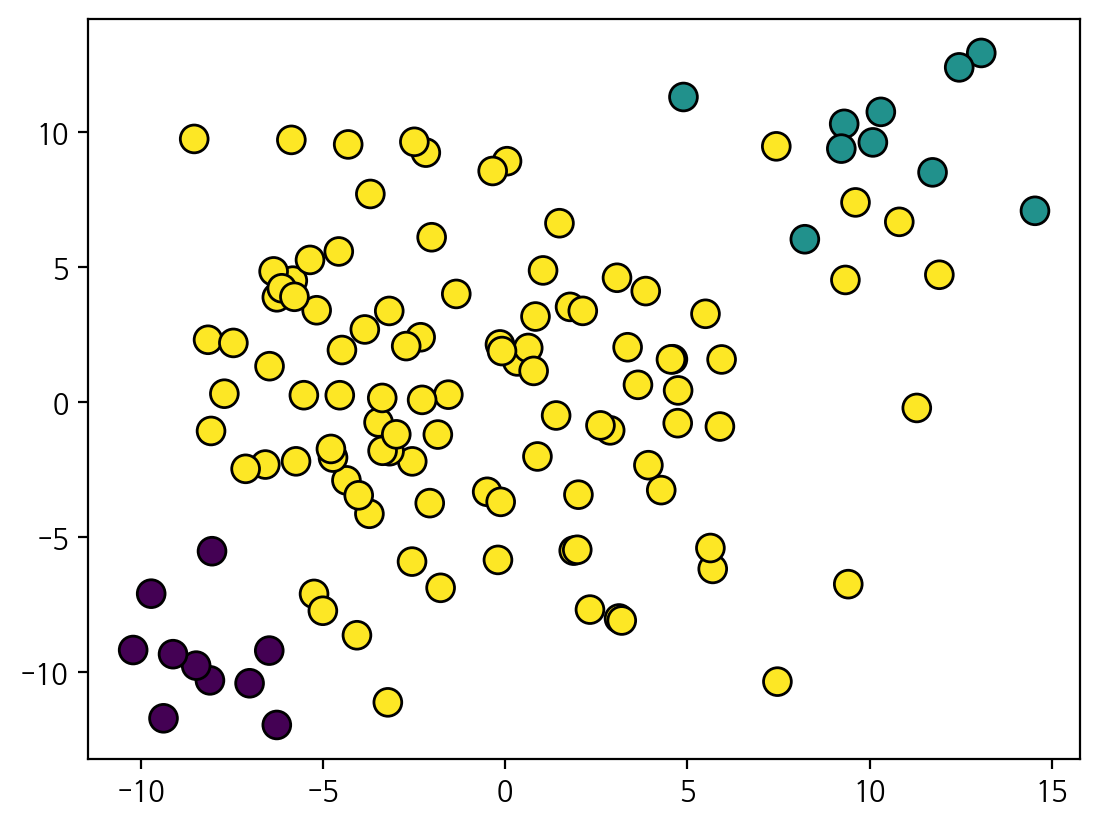

In [117]:
plt.scatter(x=data[:,0],y = data[:,1],c = data[:,2], s= 100, edgecolors='k')
plt.show()

In [118]:
model = KMeans(n_clusters=3,
              init='k-means++',
              n_init='auto',
              max_iter=300)
model.fit(data[:,:2])

KMeans(n_clusters=3, n_init='auto')

In [119]:
c = model.cluster_centers_ # 중심점
c

array([[-3.23795138,  3.79797742],
       [ 7.93234415,  5.526175  ],
       [-2.11638402, -5.40013046]])

In [121]:
model.labels_
pred = model.predict(data[:,:2])
pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0,
       2, 0, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 0, 1, 2, 2, 2, 0, 0, 2, 1, 1,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0,
       0, 0, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 2, 2, 0, 1, 0, 2, 1, 1, 2, 0,
       2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 0, 1,
       2, 0, 0, 0, 2, 2, 0, 0, 2, 0])

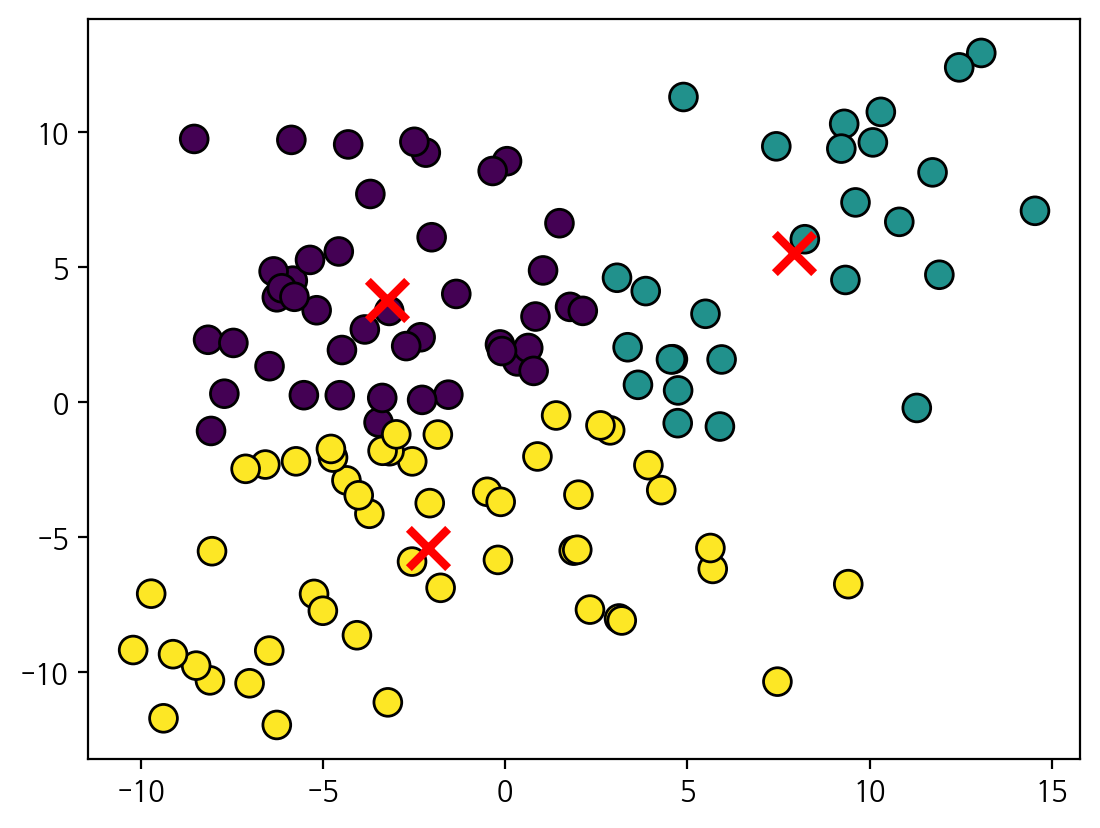

In [127]:
plt.scatter(x=data[:,0],y = data[:,1],c = pred, s= 100, edgecolors='k')
plt.scatter(x=c[:,0], y = c[:,1], c='r', marker = 'x', s=200, lw=3)
plt.show()

In [128]:
model = KMeans(n_clusters=6,
              init='k-means++',
              n_init = 10,
              max_iter=300)

model.fit(data[:,:2])

KMeans(n_clusters=6, n_init=10)

In [135]:
pred = model.labels_ # 모델 clustering 결과
c = model.cluster_centers_ # 모델 중심점 좌표들
pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 0,
       4, 0, 4, 4, 1, 5, 5, 4, 4, 3, 1, 4, 4, 5, 1, 1, 4, 4, 0, 1, 2, 5,
       0, 0, 5, 5, 0, 5, 1, 0, 0, 4, 2, 2, 0, 0, 5, 5, 1, 5, 4, 0, 5, 4,
       4, 0, 5, 1, 4, 5, 2, 0, 4, 0, 4, 1, 1, 4, 0, 5, 0, 3, 5, 5, 1, 0,
       4, 4, 1, 3, 1, 4, 0, 4, 1, 5, 5, 2, 4, 5, 1, 1, 5, 5, 1, 4, 5, 5,
       4, 4, 4, 5, 4, 4, 4, 0, 1, 5])

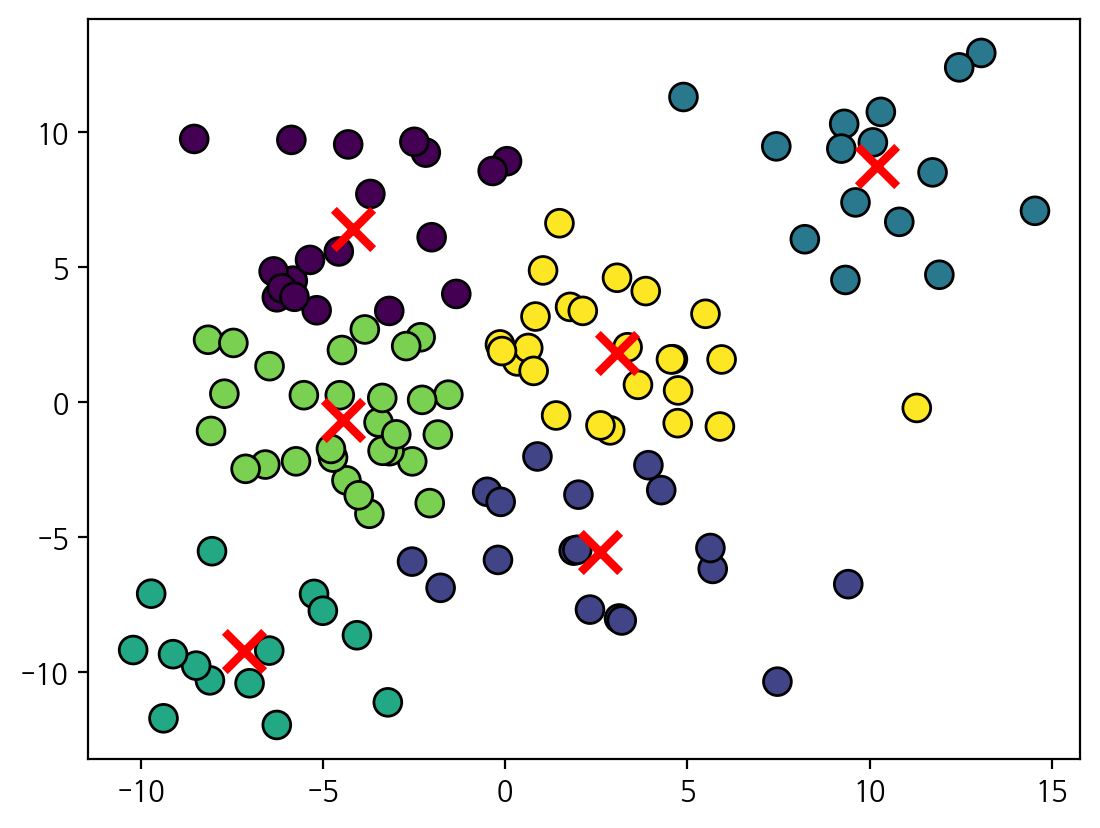

In [134]:
plt.scatter(x=data[:,0],y = data[:,1],c = pred, s= 100, edgecolors='k')
plt.scatter(x=c[:,0], y = c[:,1], c='r', marker = 'x', s=200, lw=3)
plt.show()

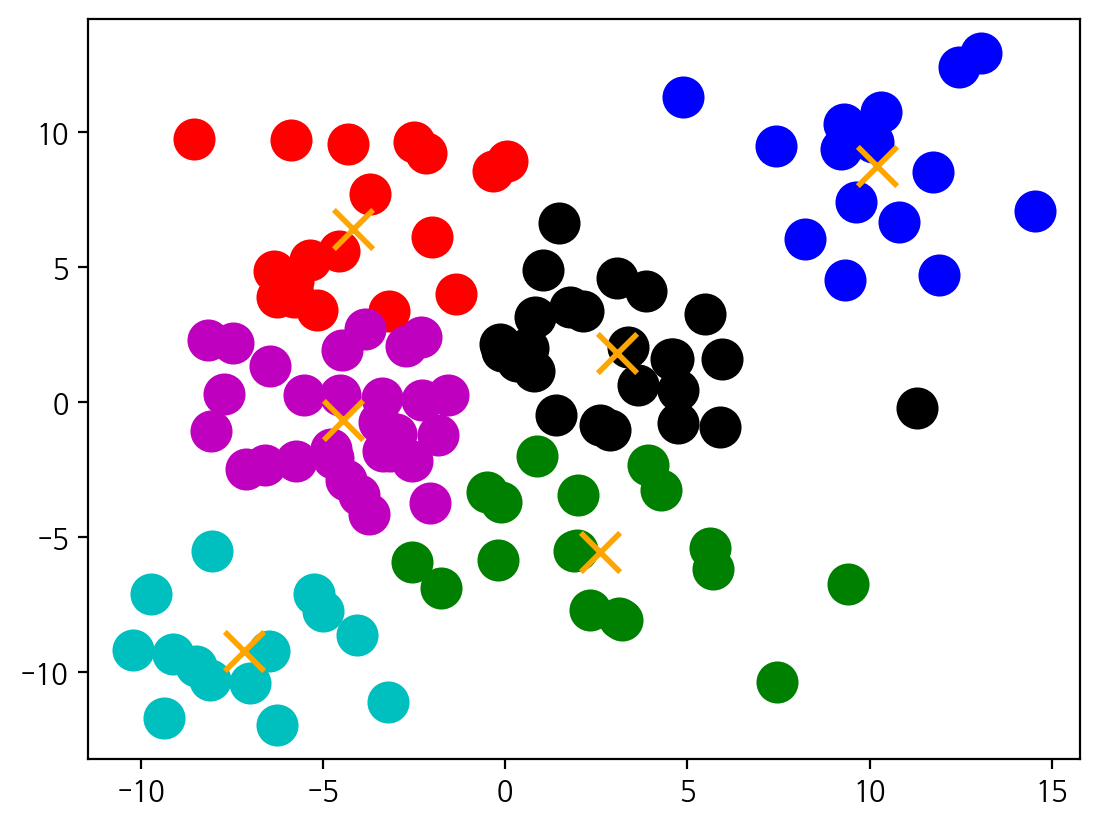

In [154]:
colors = ['r','g','b','c','m','k'] # 0 1 2 3 4 5 색 지정
for i, x in enumerate(c) : 
    plt.scatter(x=data[pred == i, 0], y = data[pred==i,1], c=colors[i], s=200)
    plt.scatter(x=x[0], y = x[1], c='orange', s=200, marker='x', linewidths=2)


# 3절. Hierarchical 클러스터링(계층적 군집)
- 군끼리 묶으면서 최종적으로 하나의 군집이 될때까지 군을 묶는 클러스터링 알고리즘
- 군집의 수를 미리 정해주지 않음
- 군집간의 거리 기반으로 클러스터링

In [156]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [158]:
# 계층적 군집 적용을 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris.species)

In [160]:
from scipy.cluster.hierarchy import linkage
# method : 거리 계산을 어떻게 할지
# method = 'complete' : 두 클러스터에서 가장 먼 거리를 이용 => 가장 보편적
# method = 'single' : 두 클러스터에서 가장 가까운 거리를 이용
# method = 'average' : 두 클러스터 내의 각 점에서 다른 클러스터의 모든 점 까지의 평균거리 이용
cluster_model = linkage(iris, method = 'complete')

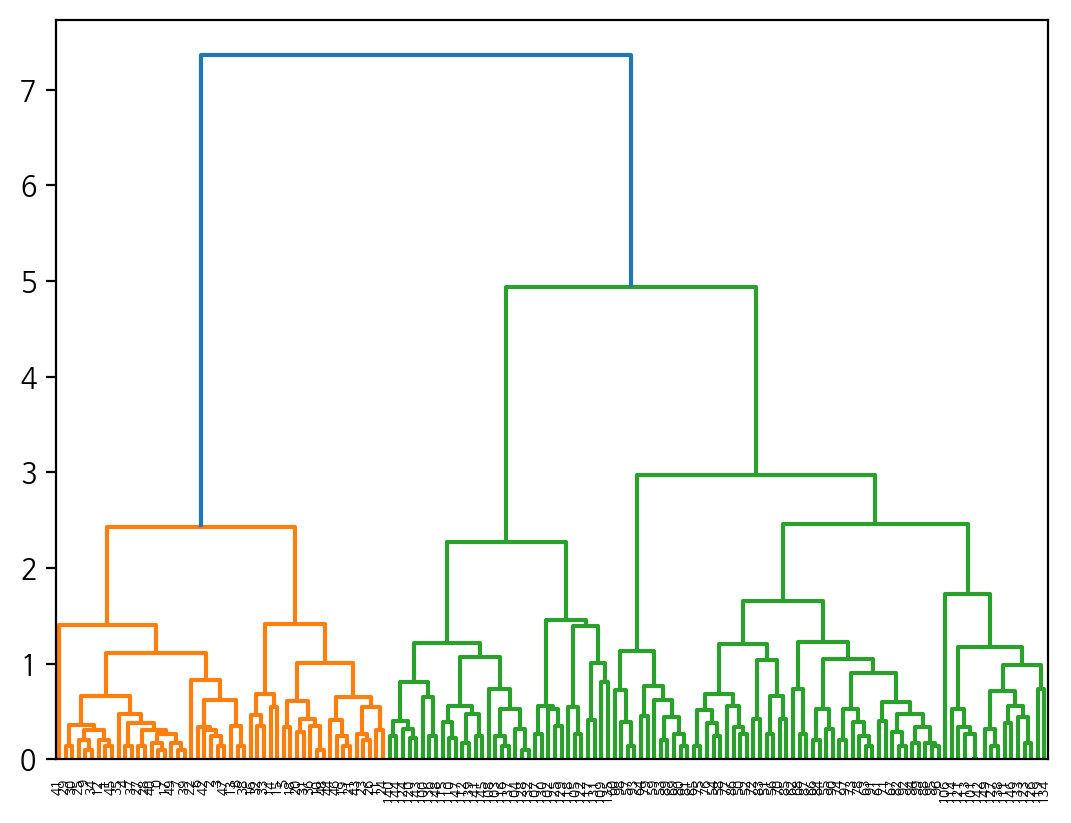

In [164]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, labels=iris.index)
plt.savefig('data/ch2_iris.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [165]:
from scipy.cluster.hierarchy import fcluster # dendrogram을 보고 군집화
fcluster(cluster_model,
         t=4, # t : dendrogram의 y 값
         criterion = 'distance', # 군집화 기준
        )
# criterion = 'distance' 일 때 t 값은 dendrogram의 y축 값

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [166]:
fcluster(cluster_model,
        t=3,
        criterion='maxclust') # 이 때 t 값은 클러스터의 개수 => 3개 군집화 하겠다

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [171]:
fcluster(cluster_model,
        t=2,
        criterion='distance')

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6,
       6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 3, 7, 4, 3, 3, 4, 7, 4, 3, 4,
       3, 7, 3, 7, 7, 3, 3, 4, 4, 7, 3, 7, 4, 7, 3, 4, 7, 7, 3, 4, 4, 4,
       3, 7, 7, 4, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 7], dtype=int32)

In [172]:
fcluster(cluster_model,
        t=2,
        criterion='maxclust')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

# 4절. DBSCAN 클러스터링
- 실무에서 사용세가 적은 편
- 연결 기반 (밀도 기반) 군집화 알고리즘 => 이상치를 자동 감지
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능 저하

In [185]:
X1 = np.random.rand(400)*3 # 0 <= X1 <3 실수 난수 200개
noise = np.random.normal(0,0.2,400)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1,Y1,np.full(X1.shape,0)]

X2 = X1 + 1.5 # 1.5 <= X2 <4.5
Y2 = np.cos(X2)+noise
group2 = np.c_[X2,Y2,np.full(X2.shape,1)]
group2

array([[ 4.28331157, -0.48763504,  1.        ],
       [ 3.43534501, -1.24738123,  1.        ],
       [ 3.39756381, -1.03778533,  1.        ],
       ...,
       [ 1.92235094, -0.44722345,  1.        ],
       [ 1.85658565, -0.19468306,  1.        ],
       [ 2.2131937 , -0.83646001,  1.        ]])

In [187]:
data = np.r_[group1, group2]
data.shape

(800, 3)

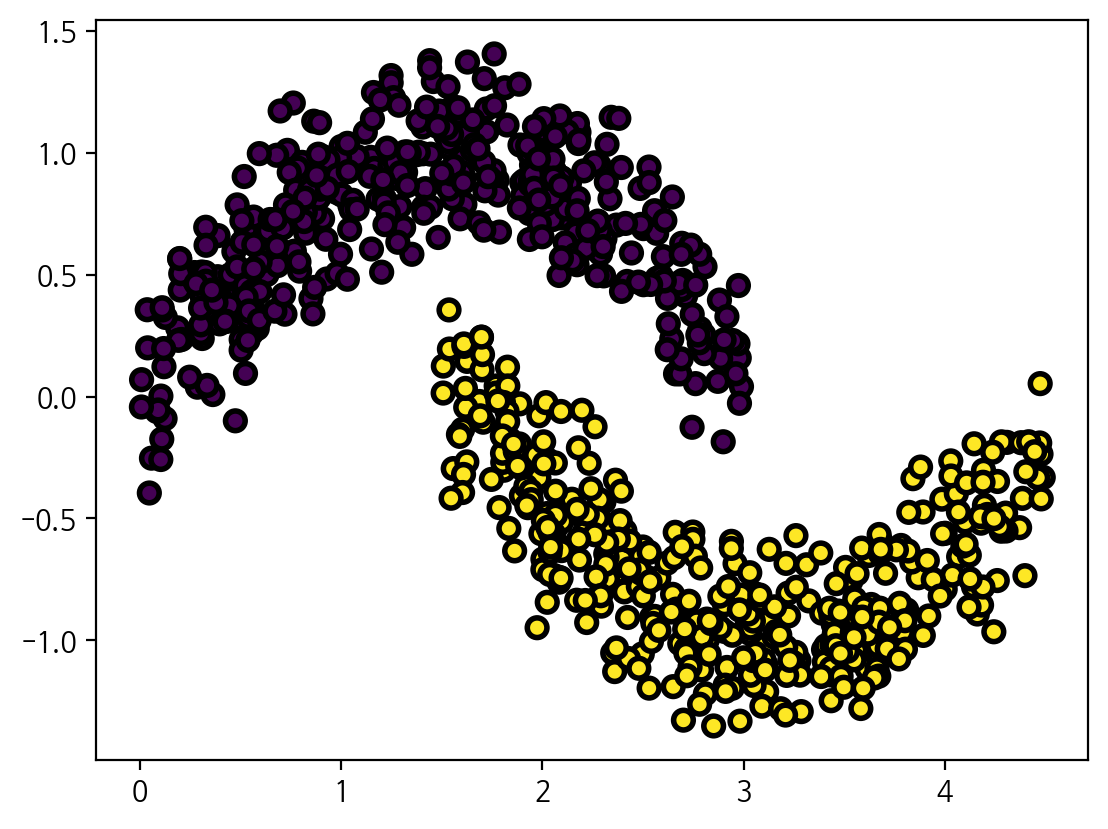

In [195]:
plt.scatter(data[:,0],data[:,1],c=data[:,2], s=50, edgecolors='k', lw=2)
plt.show()

In [196]:
data[::100]

array([[ 2.78331157,  0.27906197,  0.        ],
       [ 0.12437539, -0.0904392 ,  0.        ],
       [ 1.31996485,  0.91974478,  0.        ],
       [ 2.27196463,  0.49573461,  0.        ],
       [ 4.28331157, -0.48763504,  1.        ],
       [ 1.62437539, -0.2680476 ,  1.        ],
       [ 2.81996485, -0.9976837 ,  1.        ],
       [ 3.77196463, -1.07616272,  1.        ]])

In [207]:
from sklearn.cluster import DBSCAN
# 반경 0.3 이내에 최소 10개는 있어야 군집 시작
db = DBSCAN(eps=0.25, min_samples=10)
db.fit(data[:,:2])

DBSCAN(eps=0.25, min_samples=10)

In [213]:
labels = db.labels_ # 모델이 군집화한 결과 (-1은 이상치 인식)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) # 클러스터 수
n_noise_ = list(labels).count(-1)
print('이상치를 제외한 클러스터 수 :', n_clusters_)
print('이상치 개수 :',n_noise_)

이상치를 제외한 클러스터 수 : 2
이상치 개수 : 1


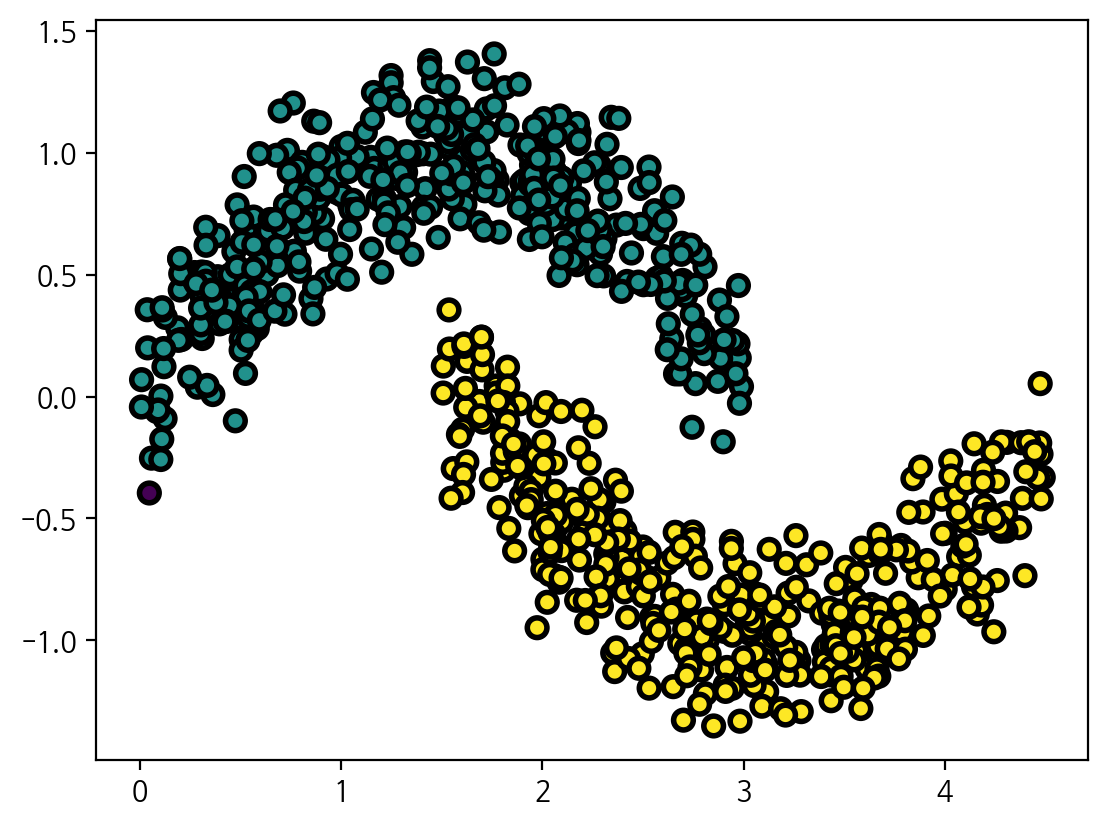

In [215]:
plt.scatter(data[:,0],data[:,1],c=labels, s=50, edgecolors='k', lw=2)
plt.show()

In [222]:
labels.tolist().index(-1)

259

# 5절. 모형 성능 평가
- score 메소드를 통해 예측 모형을 평가(분류, 회귀) => 군집모형에서는 활용하지 않음
- metrics 모듈의 메소드를 통해 모형 평가

## 5.1 metrics 함수 이용
     - 클러스터의 소속, 개수를 모두 알고 있을 경우 평가

In [226]:
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:,-1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [241]:
# 3개 cluster로 분류
iris_model3 = KMeans(n_clusters=3,n_init=10,random_state=1)
iris_model3.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [232]:
pred = iris_model3.labels_
pred = iris_model3.predict(iris_X)
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [234]:
# predict 조정을 위해 np.choose(배열 인덱스 리스트, 배열) 
np.choose([3,2,2,3], [0,10,20,30])

array([30, 20, 20, 30])

In [236]:
pred3 = np.choose(pred, [1,0,2]) # 조정된 예측값
pred3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [240]:
# 3개 cluster로 군집화 한 자료
print('실제값 :',iris_y[::50])
print('예측값 :',pred3[::50])

실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [245]:
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1] * 100)
print('실제값 :',iris_y2)

실제값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [246]:
iris_model2 = KMeans(n_clusters=2,n_init=10,random_state=1)
iris_model2.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [249]:
pred2 = iris_model2.labels_
pred2
# 분류를 0과 1로 하여 조정 불필요

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [250]:
# 2개 cluster로 군집화 한 자료
print('실제값 :',iris_y2[::50])
print('예측값 :',pred2[::50])

실제값 : [0 1 1]
예측값 : [0 1 1]


In [251]:
# 클러스터가 3개인 경우 평가
from sklearn.metrics import adjusted_rand_score # 두 군집 라벨의 쌍 일치 정도 (1: 완벽, 0: 랜덤, 음수: 역상관)
adjusted_rand_score(iris_y, pred3)

0.7302382722834697

In [252]:
# 클러스터가 2개인 경우 평가
adjusted_rand_score(iris_y2, pred2)

0.920405050901892

In [253]:
from sklearn.metrics import mutual_info_score # 정보이론적 유사성 (값이 높을수록 두 군집 간 정보 공유가 많음) : 상호 의존도를 나타내는 지표
# 클러스터가 3개인 경우 평가 
mutual_info_score(iris_y, pred3)

0.8255910976103356

In [254]:
# 클러스터가 2개인 경우 평가
mutual_info_score(iris_y2, pred2)

0.5596576064224734

In [255]:
from sklearn.metrics import v_measure_score
# 클러스터 3개
print(v_measure_score(iris_y, pred3))
# 클러스터 2개
print(v_measure_score(iris_y2, pred2))

0.7581756800057784
0.870385156563164


In [256]:
# 위 지표들을 체크하면서 클러스터 개수를 체크한다.

## 5.2 실루엣 계수
- cluster의 개수 및 소속을 모를 때 평가하는 방법

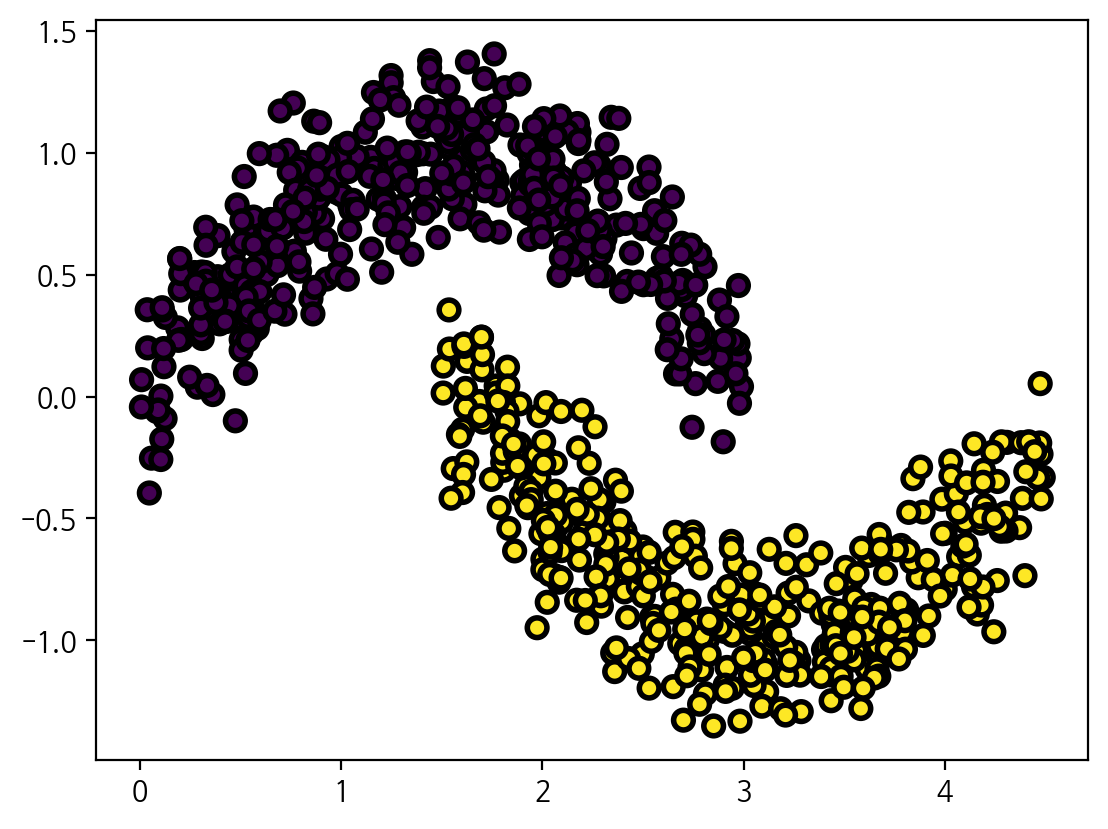

In [259]:
X1 = np.random.rand(400)*3 # 0 <= X1 <3 실수 난수 200개
noise = np.random.normal(0,0.2,400)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1,Y1,np.full(X1.shape,0)]

X2 = X1 + 1.5 # 1.5 <= X2 <4.5
Y2 = np.cos(X2)+noise
group2 = np.c_[X2,Y2,np.full(X2.shape,1)]
group2

plt.scatter(data[:,0],data[:,1],c=data[:,2], s=50, edgecolors='k', lw=2)
plt.show()

In [271]:
from sklearn.metrics import silhouette_score
range_n_clusters = [i for i in range(2,11)]
for n_clusters in range_n_clusters :
    model = KMeans(n_clusters=n_clusters,
                  n_init = 10,
                  random_state=2)
    model.fit(data[:,:2])
    pred = model.labels_
    score = silhouette_score(X = data[:,:2],
                            labels = pred)
    print(f"클러스트수 : {n_clusters}, 실루엣 계수 : {score}")

클러스트수 : 2, 실루엣 계수 : 0.5302050582100583
클러스트수 : 3, 실루엣 계수 : 0.45777563382883757
클러스트수 : 4, 실루엣 계수 : 0.4788798257379819
클러스트수 : 5, 실루엣 계수 : 0.46572516626941396
클러스트수 : 6, 실루엣 계수 : 0.46770713942236186
클러스트수 : 7, 실루엣 계수 : 0.4682186638391969
클러스트수 : 8, 실루엣 계수 : 0.45932172384048714
클러스트수 : 9, 실루엣 계수 : 0.4654096005600506
클러스트수 : 10, 실루엣 계수 : 0.46114286204020244


In [272]:
# 실루엣 계수가 가장 높은 2 => 6, 6개로 해보기
model = KMeans(n_clusters=6,
                  n_init = 10,
                  random_state=2)
model.fit(data[:,:2])
pred = model.labels_

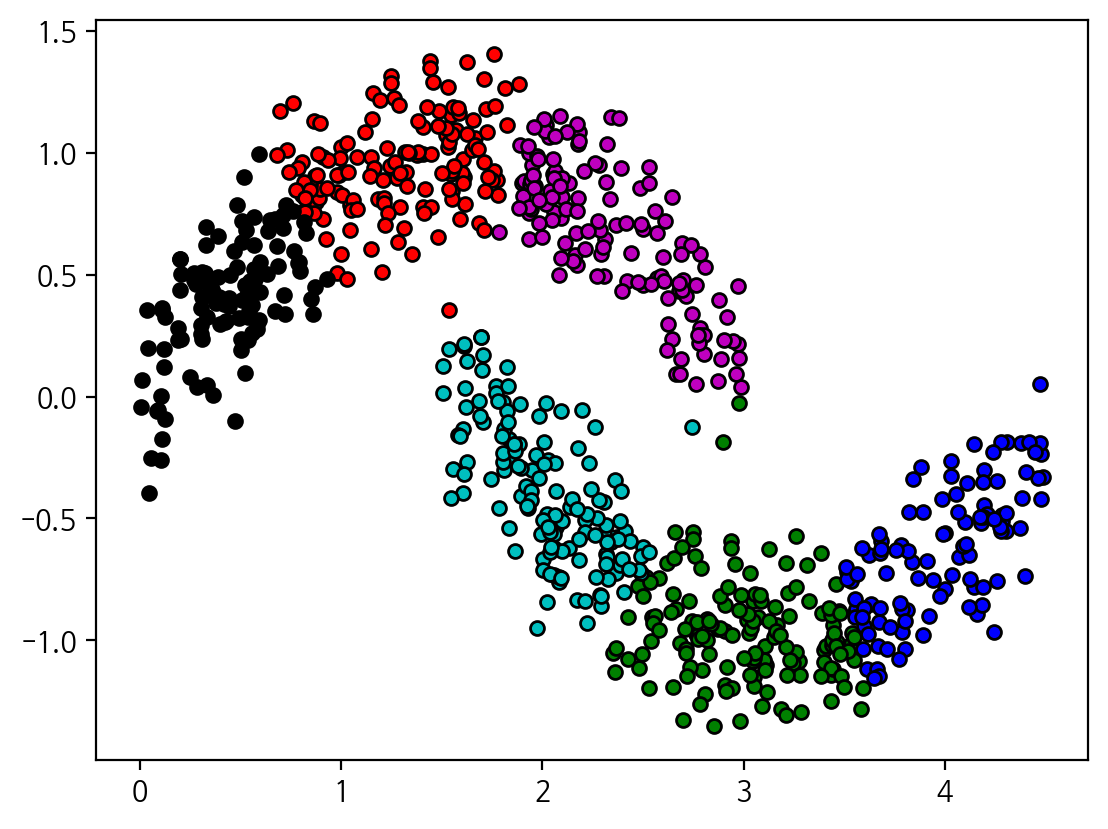

In [278]:
centers = model.cluster_centers_
colors = ['r','g','b','c','m','k'] # group1 : idx 5, 0, 4 // group2 : idx 1,2,3
for i,rr in enumerate(colors) :
    plt.scatter(x = data[pred==i, 0], y=data[pred==i, 1], c=rr, s=25, edgecolors='k')
plt.show()